<a href="https://colab.research.google.com/github/karthikmateti/Multi-Agent-Resume-Hiring/blob/main/Updated_single_LLMs_resume_hiring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Single LLM Baseline
#
# CELL 1 : INSTALL REQUIRED LIBRARIES
# ============================================================

print("=" * 80)
print("Installing Required Libraries")
print("=" * 80)

!pip -q install --upgrade pip

# Core Libraries
!pip -q install pandas numpy scipy scikit-learn openpyxl

# OpenRouter Client
!pip -q install openai

# Embedding (kept for consistency, although not used in baseline)
!pip -q install sentence-transformers

# Visualization
!pip -q install matplotlib seaborn

# Utilities
!pip -q install tqdm python-dotenv

print("=" * 80)
print("Libraries Installed Successfully")
print("=" * 80)

Installing Required Libraries
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.0 MB/s eta 0:00:00
Libraries Installed Successfully


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Single LLM Baseline
#
# CELL 2 : IMPORTS & ENVIRONMENT SETUP
# ============================================================

import os
import json
import re
import random
import warnings
from getpass import getpass

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

# ============================================================
# OpenRouter Client
# ============================================================

from openai import OpenAI

# ============================================================
# Statistics
# ============================================================

from scipy.stats import pearsonr, spearmanr

from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score

)

# ============================================================
# Visualization
# ============================================================

import matplotlib.pyplot as plt

import seaborn as sns

# ============================================================
# Google Colab Upload
# ============================================================

from google.colab import files

# ============================================================
# SETTINGS
# ============================================================

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (10,6)

plt.rcParams["axes.grid"] = True

pd.set_option("display.max_columns", None)

pd.set_option("display.max_colwidth", 200)

print("="*80)

print("Environment Initialized Successfully")

print("="*80)

print(f"Numpy Version  : {np.__version__}")

print(f"Pandas Version : {pd.__version__}")

print()

print("Single LLM Baseline Ready")

print("="*80)

Environment Initialized Successfully
Numpy Version  : 2.0.2
Pandas Version : 2.2.2

Single LLM Baseline Ready


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Single LLM Baseline
#
# CELL 3 : OPENROUTER CONFIGURATION (7 API KEYS)
# ============================================================

from getpass import getpass
from openai import OpenAI

print("=" * 80)
print("OPENROUTER CONFIGURATION")
print("=" * 80)

# ============================================================
# ENTER OPENROUTER API KEYS
# ============================================================

OPENROUTER_KEYS = [

    getpass("Enter OpenRouter API Key 1 : "),

    getpass("Enter OpenRouter API Key 2 : "),

    getpass("Enter OpenRouter API Key 3 : "),

    getpass("Enter OpenRouter API Key 4 : "),

    getpass("Enter OpenRouter API Key 5 : "),

    getpass("Enter OpenRouter API Key 6 : "),

    getpass("Enter OpenRouter API Key 7 : ")

]

# ============================================================
# MODEL
# ============================================================

MODEL_NAME = "deepseek/deepseek-chat"

print()
print("Model Selected :", MODEL_NAME)
print()

# ============================================================
# CREATE CLIENTS
# ============================================================

clients = []

for key in OPENROUTER_KEYS:

    clients.append(

        OpenAI(

            api_key=key,

            base_url="https://openrouter.ai/api/v1"

        )

    )

print(f"{len(clients)} OpenRouter Clients Created\n")

# ============================================================
# TEST EACH API KEY
# ============================================================

working_clients = []

for i, client in enumerate(clients):

    print("=" * 80)
    print(f"Testing API Key {i+1}")
    print("=" * 80)

    try:

        response = client.chat.completions.create(

            model=MODEL_NAME,

            messages=[
                {
                    "role": "user",
                    "content": "Reply ONLY with SUCCESS."
                }
            ],

            temperature=0,

            max_tokens=10

        )

        print("✅ Connection Successful")
        print("Response :", response.choices[0].message.content)

        working_clients.append(client)

    except Exception as e:

        print("❌ Connection Failed")
        print(e)

    print()

# ============================================================
# VERIFY WORKING CLIENTS
# ============================================================

if len(working_clients) == 0:

    raise RuntimeError("No valid OpenRouter API Keys found.")

clients = working_clients

client = clients[0]

print("=" * 80)
print("OPENROUTER READY")
print("=" * 80)

print(f"Working API Keys : {len(clients)}")

print("=" * 80)

OPENROUTER CONFIGURATION
Enter OpenRouter API Key 1 : ··········
Enter OpenRouter API Key 2 : ··········
Enter OpenRouter API Key 3 : ··········
Enter OpenRouter API Key 4 : ··········
Enter OpenRouter API Key 5 : ··········
Enter OpenRouter API Key 6 : ··········
Enter OpenRouter API Key 7 : ··········

Model Selected : deepseek/deepseek-chat

7 OpenRouter Clients Created

Testing API Key 1
✅ Connection Successful
Response : SUCCESS

Testing API Key 2
✅ Connection Successful
Response : SUCCESS

Testing API Key 3
✅ Connection Successful
Response : SUCCESS

Testing API Key 4
✅ Connection Successful
Response : SUCCESS

Testing API Key 5
✅ Connection Successful
Response : SUCCESS

Testing API Key 6
✅ Connection Successful
Response : SUCCESS

Testing API Key 7
✅ Connection Successful
Response : SUCCESS

OPENROUTER READY
Working API Keys : 7


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Single LLM Baseline
#
# CELL 4 : LOAD & VALIDATE DATASET
# ============================================================

print("=" * 80)
print("Loading CareerCorpus Dataset")
print("=" * 80)

# ------------------------------------------------------------
# Upload Dataset
# ------------------------------------------------------------

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No dataset uploaded.")

dataset_path = list(uploaded.keys())[0]

print(f"\nDataset Uploaded : {dataset_path}")

# ------------------------------------------------------------
# Read Excel File
# ------------------------------------------------------------

try:
    df = pd.read_excel(dataset_path)

except Exception as e:

    raise RuntimeError(f"Unable to read dataset : {e}")

print("\nDataset Loaded Successfully")

# ------------------------------------------------------------
# Standardize Column Names
# ------------------------------------------------------------

df.columns = (

    df.columns

    .str.strip()

    .str.replace("\n", " ", regex=False)

)

# ------------------------------------------------------------
# Dataset Information
# ------------------------------------------------------------

print("\nDataset Shape")

print(df.shape)

print("\nColumns\n")

for i, col in enumerate(df.columns, 1):

    print(f"{i}. {col}")

print("\nMissing Values\n")

display(df.isnull().sum())

print("\nFirst Five Records\n")

display(df.head())

# ------------------------------------------------------------
# Required Columns
# ------------------------------------------------------------

required_columns = [

    "ID",

    "Domain",

    "Education",

    "Skills and Achievements",

    "Experience",

    "Job_type",

    "Annotator-1",

    "Annotator-2"

]

missing_columns = [

    c

    for c in required_columns

    if c not in df.columns

]

if missing_columns:

    raise ValueError(

        f"Missing Columns : {missing_columns}"

    )

print("\nAll Required Columns Found")

# ------------------------------------------------------------
# Remove Duplicate Rows
# ------------------------------------------------------------

before = len(df)

df = df.drop_duplicates()

after = len(df)

print(f"\nDuplicate Rows Removed : {before-after}")

# ------------------------------------------------------------
# Reset Index
# ------------------------------------------------------------

df = df.reset_index(drop=True)

# ------------------------------------------------------------
# Dataset Summary
# ------------------------------------------------------------

print("\nSummary\n")

print(f"Total Resumes : {len(df)}")

print(f"Domains       : {df['Domain'].nunique()}")

print(f"Job Types     : {df['Job_type'].nunique()}")

print()

print("=" * 80)
print("Dataset Validation Completed")
print("=" * 80)

Loading CareerCorpus Dataset


Saving CareerCorpus.xlsx to CareerCorpus.xlsx

Dataset Uploaded : CareerCorpus.xlsx

Dataset Loaded Successfully

Dataset Shape
(302, 8)

Columns

1. ID
2. Domain
3. Education
4. Skills and Achievements
5. Experience
6. Job_type
7. Annotator-1
8. Annotator-2

Missing Values



,0
ID,0
Domain,0
Education,0
Skills and Achievements,0
Experience,0
Job_type,0
Annotator-1,0
Annotator-2,0



First Five Records



,ID,Domain,Education,Skills and Achievements,Experience,Job_type,Annotator-1,Annotator-2
0,74552449,Banking,"Master of Science in International Trade, Universidad Carlos III de Madrid, Spain (2014) — coursework in international trade policies and laws. Bachelor of Science in Business Administration and D...","Skilled in cash handling, loan operations, financial reporting, analysis, and risk identification. Proficient in MS Excel and MS Office; adept at business negotiation, communication, and team lead...","Professional (11/2016–Present)—opened and managed customer accounts (checking, savings, credit lines), balanced vault inventory with zero error rate, ensured regulatory compliance, and provided cl...",Entry-level,0.80,0.88
1,79041971,Banking,"High School Diploma, Federal Way Senior High School, United States (2010","Strong leadership, team management, and client relations abilities. Skilled in supervision, staff training, multitasking, and decision-making under pressure. Proficient in recruiting, sales growth...","Banking Professional (Aug 2013–Present)—oversees daily operations, client service, and staff performance within the banking domain. Store Manager (Aug 2012–Nov 2012)—managed team of 10; launched n...",Mid-level,0.40,0.75
2,77156708,Banking,"Master of Management, Business Management — Colorado State University (05/2017). Bachelor of Arts, Applied Economics — National University of Kaohsiung, Taiwan (05/2013).",NMLS #1796859; business development; project management; Confluence/Jira/Salesforce/SQL; financial analysis & statements; pricing strategy; budgeting; credit/underwriting; due diligence; documenta...,Banking Officer (10/2018–Current)—BSA/AML/OFAC compliance; credit analysis & underwriting; top producer; realtor & SMB relationships; supervised Asian Banking Center and community outreach. Direct...,Mid-level,0.84,0.97
3,24580361,Banking,"B.S. in Operations Management, University of Delaware (2013); Minor in Economics; GPA 3.978/4.0. Awards: Distinguished Operations Management Junior, Alpha Lambda Delta, National Society of Collegi...","Microsoft Office (Excel/PowerPoint/Word/Access), SAP, Minitab, Maple, Lingo, HTML; Six Sigma exposure; detail-oriented, analytical, troubleshooting/problem solving; strong communication, time mana...","Associate, Investment Banking Operations (07/2013–Present)—operations role (firm/city undisclosed). Intern, Syndicated Loan Operations (06/2012–12/2012)—maintained 150+ deals/1000+ loans; processe...",Senior-level,0.76,0.97
4,34953092,Banking,"M.S. Computer Engineering, University of Missouri–Columbia (2016), GPA 3.46; Graduate Research Assistant. B.S. Finance & Banking, University of Missouri–Columbia (2013), Minor in Mathematics; VP, ...","C/C++, Python, MATLAB, SQL, R, LUA, VBA; ML (supervised/unsupervised/DNN); forecasting & financial analysis; English/Chinese. Built VBA systems improving workflow (up to 20%); SQL research; image-...","Corporate Banking Assistant, Intern (May–Aug 2015)—commercial mortgage risk reports (appraisal, cash flow, RAROC, sensitivity), SME research in SQL, VBA documentation system. Office Assistant, Int...",Entry-level,0.76,0.88



All Required Columns Found

Duplicate Rows Removed : 0

Summary

Total Resumes : 302
Domains       : 6
Job Types     : 4

Dataset Validation Completed


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Single LLM Baseline
#
# CELL 5 : RESUME PREPROCESSING
# ============================================================

print("=" * 80)
print("Resume Preprocessing")
print("=" * 80)

# ------------------------------------------------------------
# Fill Missing Values
# ------------------------------------------------------------

text_columns = [

    "Education",

    "Skills and Achievements",

    "Experience",

    "Domain",

    "Job_type"

]

for col in text_columns:

    df[col] = (

        df[col]

        .fillna("Not Available")

        .astype(str)

    )

# ------------------------------------------------------------
# Ground Truth Score
# ------------------------------------------------------------

df["ground_truth_score"] = (

    df["Annotator-1"]

    +

    df["Annotator-2"]

) / 2

# ------------------------------------------------------------
# Resume Constructor
# ------------------------------------------------------------

def build_resume(row):

    return f"""
Domain:
{row['Domain']}

Target Job:
{row['Job_type']}

Education:
{row['Education']}

Skills and Achievements:
{row['Skills and Achievements']}

Experience:
{row['Experience']}
""".strip()

df["resume_text"] = df.apply(

    build_resume,

    axis=1

)

# ------------------------------------------------------------
# Resume Cleaning
# ------------------------------------------------------------

def clean_resume(text):

    text = re.sub(

        r"\n+",

        "\n",

        text

    )

    text = re.sub(

        r"\s+",

        " ",

        text

    )

    return text.strip()

df["resume_text"] = df["resume_text"].apply(

    clean_resume

)

# ------------------------------------------------------------
# Resume Statistics
# ------------------------------------------------------------

df["word_count"] = (

    df["resume_text"]

    .apply(lambda x: len(x.split()))

)

df["character_count"] = (

    df["resume_text"]

    .apply(len)

)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print()

print(f"Total Resumes : {len(df)}")

print()

print(

    f"Average Resume Length : "

    f"{df['word_count'].mean():.2f} words"

)

print()

print("Sample Resume\n")

print(df.loc[0,"resume_text"][:1000])

print()

print("=" * 80)

print("Resume Preprocessing Completed")

print("=" * 80)

Resume Preprocessing

Total Resumes : 302

Average Resume Length : 111.59 words

Sample Resume

Domain: Banking Target Job: Entry-level Education: Master of Science in International Trade, Universidad Carlos III de Madrid, Spain (2014) — coursework in international trade policies and laws. Bachelor of Science in Business Administration and Direction, Universidad Pública de Navarra, Spain (2013) Skills and Achievements: Skilled in cash handling, loan operations, financial reporting, analysis, and risk identification. Proficient in MS Excel and MS Office; adept at business negotiation, communication, and team leadership. Multilingual (Spanish). Experienced with Salesforce, TapScan, Photoshop, Illustrator, HTML, and public relations tools such as Factiva and Bacon’s Mediasource. Recognized for client interfacing and developing marketing strategies to drive business growth Experience: Professional (11/2016–Present)—opened and managed customer accounts (checking, savings, credit lines), bal

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Single LLM Baseline
#
# CELL 6 : SHARED UTILITY FUNCTIONS
# ============================================================

print("=" * 80)
print("Initializing Utility Functions")
print("=" * 80)

import time
import json
import re

# ============================================================
# OpenRouter Chat Function
# ============================================================

def chat_with_llm(
    system_prompt,
    user_prompt,
    model=MODEL_NAME,
    temperature=0,
    max_tokens=500,
    retries=3
):

    for attempt in range(retries):

        try:

            response = client.chat.completions.create(

                model=model,

                temperature=temperature,

                max_tokens=max_tokens,

                messages=[

                    {

                        "role":"system",

                        "content":system_prompt

                    },

                    {

                        "role":"user",

                        "content":user_prompt

                    }

                ]

            )

            return response.choices[0].message.content.strip()

        except Exception as e:

            print(

                f"Retry {attempt+1}/{retries} : {e}"

            )

            time.sleep(2)

    raise RuntimeError(

        "LLM request failed."

    )

# ============================================================
# Extract JSON
# ============================================================

def extract_json(text):

    text = text.strip()

    match = re.search(

        r"\{.*\}",

        text,

        re.DOTALL

    )

    if match:

        try:

            return json.loads(

                match.group()

            )

        except:

            pass

    try:

        return json.loads(text)

    except:

        raise ValueError(

            "No valid JSON found."

        )

# ============================================================
# Normalize Score
# ============================================================

def normalize_score(

    score,

    minimum=0,

    maximum=10

):

    score = float(score)

    score = max(minimum, score)

    score = min(maximum, score)

    return round(score,2)

# ============================================================
# Pretty JSON
# ============================================================

def pretty_json(data):

    print(

        json.dumps(

            data,

            indent=4,

            ensure_ascii=False

        )

    )

print()

print("Utility Functions Ready")

print("=" * 80)

Initializing Utility Functions

Utility Functions Ready


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Single LLM Baseline
#
# CELL 7 : SINGLE LLM EVALUATOR
# ============================================================

print("=" * 80)
print("Initializing Single LLM Evaluator")
print("=" * 80)

# ============================================================
# SYSTEM PROMPT
# ============================================================

SINGLE_LLM_SYSTEM_PROMPT = """
You are an experienced hiring manager.

Evaluate the candidate's resume based ONLY on the information provided.

Consider the following criteria:

1. Education
2. Technical Skills
3. Relevant Experience
4. Domain Knowledge
5. Achievements
6. Overall Resume Quality
7. Suitability for the Target Job

Do NOT invent information.

Base your evaluation only on evidence available in the resume.

Assign a FINAL hiring score between 0 and 10.

Hiring Decision Rules

8.0 - 10.0  -> Hire

5.0 - 7.99  -> Hold

0.0 - 4.99  -> Reject

Return ONLY valid JSON.

{

    "score":0,

    "decision":"Hire",

    "reasoning":""

}
"""

# ============================================================
# SINGLE LLM AGENT
# ============================================================

def single_llm_agent(resume_text):

    user_prompt = f"""

Evaluate the following resume.

Resume

{resume_text}

"""

    response = chat_with_llm(

        system_prompt=SINGLE_LLM_SYSTEM_PROMPT,

        user_prompt=user_prompt,

        temperature=0,

        max_tokens=250

    )

    try:

        result = extract_json(response)

    except Exception:

        result = {

            "score":0,

            "decision":"Reject",

            "reasoning":response

        }

    result["score"] = normalize_score(

        result.get("score",0)

    )

    score = result["score"]

    # --------------------------------------------------------
    # Standardize Decision
    # --------------------------------------------------------

    if score >= 8:

        result["decision"] = "Hire"

    elif score >= 5:

        result["decision"] = "Hold"

    else:

        result["decision"] = "Reject"

    return result

# ============================================================
# TEST SINGLE LLM
# ============================================================

print()

print("Testing Single LLM...\n")

sample_resume = df.loc[0, "resume_text"]

result = single_llm_agent(

    sample_resume

)

pretty_json(result)

print()

print("=" * 80)

print("Single LLM Ready")

print("=" * 80)

Initializing Single LLM Evaluator

Testing Single LLM...

{
    "score": 7.5,
    "decision": "Hold",
    "reasoning": "The candidate has a strong educational background with a Master's degree in International Trade and a Bachelor's degree in Business Administration, which is relevant to the banking domain. They possess technical skills in financial reporting, analysis, and risk identification, along with proficiency in MS Excel and MS Office. The candidate has relevant experience in banking operations, account management, and customer support, with a notable achievement of balancing vault inventory with a zero error rate. However, the resume lacks specific achievements or quantifiable results that demonstrate significant impact in their previous roles. The overall resume quality is good, but it could benefit from more detailed accomplishments and metrics. The candidate is suitable for an entry-level banking position, but the lack of standout achievements warrants a 'Hold' decision."
}

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Single LLM Baseline
#
# CELL 8 : BATCH EVALUATION (PART 1)
# ============================================================

print("=" * 80)
print("Running Complete Dataset Evaluation")
print("=" * 80)

import math

# ============================================================
# INITIALIZATION
# ============================================================

all_results = []

TOTAL_RESUMES = len(df)

NUM_KEYS = len(clients)

BATCH_SIZE = math.ceil(TOTAL_RESUMES / NUM_KEYS)

print(f"Total Resumes : {TOTAL_RESUMES}")
print(f"API Keys      : {NUM_KEYS}")
print(f"Batch Size    : {BATCH_SIZE}")

print()

successful = 0
failed = 0

# ============================================================
# PROCESS USING EACH API KEY
# ============================================================

for key_index in range(NUM_KEYS):

    print("=" * 80)
    print(f"Using API Key {key_index+1}/{NUM_KEYS}")
    print("=" * 80)

    # ----------------------------------------
    # Switch Client
    # ----------------------------------------

    client = clients[key_index]

    # ----------------------------------------
    # Calculate Resume Range
    # ----------------------------------------

    start = key_index * BATCH_SIZE

    end = min(

        (key_index + 1) * BATCH_SIZE,

        TOTAL_RESUMES

    )

    print()

    print("=" * 80)

    print(f"API KEY {key_index+1}")

    print(f"Processing Resume {start} -> {end-1}")

    print("=" * 80)

    # ----------------------------------------
    # Process Batch
    # ----------------------------------------

    for idx in tqdm(range(start, end)):

        try:

            resume_text = df.loc[idx, "resume_text"]

            prediction = single_llm_agent(

                resume_text

            )

            result = {

                "resume_id":

                    df.loc[idx, "ID"],

                "domain":

                    df.loc[idx, "Domain"],

                "predicted_score":

                    prediction["score"],

                "ground_truth_score":

                    float(

                        df.loc[idx, "ground_truth_score"]

                    ),

                "decision":

                    prediction["decision"],

                "reasoning":

                    prediction["reasoning"]

            }

            all_results.append(

                result

            )

            successful += 1

        except Exception as e:

            print()

            print(f"Resume {idx} Failed")

            print(e)

            failed += 1

            continue

print()

print("=" * 80)

print("ALL API KEYS FINISHED")

print("=" * 80)

print(f"Successful : {successful}")

print(f"Failed     : {failed}")

print()

print("Proceed to Cell 9")

print("=" * 80)

Running Complete Dataset Evaluation
Total Resumes : 302
API Keys      : 7
Batch Size    : 44

Using API Key 1/7

API KEY 1
Processing Resume 0 -> 43


  0%|          | 0/44 [00:00<?, ?it/s]

Using API Key 2/7

API KEY 2
Processing Resume 44 -> 87


  0%|          | 0/44 [00:00<?, ?it/s]

Using API Key 3/7

API KEY 3
Processing Resume 88 -> 131


...

Using API Key 6/7

API KEY 6
Processing Resume 220 -> 263


  0%|          | 0/44 [00:00<?, ?it/s]

Using API Key 7/7

API KEY 7
Processing Resume 264 -> 301


  0%|          | 0/38 [00:00<?, ?it/s]


ALL API KEYS FINISHED
Successful : 302
Failed     : 0

Proceed to Cell 9


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Single LLM Baseline
#
# CELL 9 : CREATE RESULTS & SAVE OUTPUTS
# ============================================================

print("=" * 80)
print("Creating Evaluation DataFrame")
print("=" * 80)

import os
import json
import numpy as np

# ============================================================
# CREATE DATAFRAME
# ============================================================

evaluation_df = pd.DataFrame(all_results)

print()

display(evaluation_df.head())

print()

print("Evaluation Shape :", evaluation_df.shape)

# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "single_llm_results"

os.makedirs(

    OUTPUT_DIR,

    exist_ok=True

)

CSV_PATH = os.path.join(

    OUTPUT_DIR,

    "evaluation_results.csv"

)

JSON_PATH = os.path.join(

    OUTPUT_DIR,

    "complete_results.json"

)

# ============================================================
# SAVE CSV
# ============================================================

evaluation_df.to_csv(

    CSV_PATH,

    index=False

)

# ============================================================
# CONVERT NUMPY TYPES
# ============================================================

def convert_numpy(obj):

    if isinstance(obj, np.integer):

        return int(obj)

    elif isinstance(obj, np.floating):

        return float(obj)

    elif isinstance(obj, np.ndarray):

        return obj.tolist()

    return str(obj)

# ============================================================
# SAVE JSON
# ============================================================

with open(

    JSON_PATH,

    "w"

) as f:

    json.dump(

        all_results,

        f,

        indent=2,

        default=convert_numpy

    )

# ============================================================
# DISPLAY SAMPLE RESULTS
# ============================================================

print()

print("=" * 80)

print("RESULT FILES")

print("=" * 80)

print(f"CSV  : {CSV_PATH}")

print(f"JSON : {JSON_PATH}")

print()

print("=" * 80)

print("SAMPLE RESULTS")

print("=" * 80)

display(

    evaluation_df.head(10)

)

print()

print("=" * 80)

print("SUMMARY")

print("=" * 80)

print(f"Total Resumes : {len(evaluation_df)}")

print(f"Average Predicted Score : {evaluation_df['predicted_score'].mean():.2f}")

print(f"Average Ground Truth    : {evaluation_df['ground_truth_score'].mean():.2f}")

print()

print("Decision Distribution")

display(

    evaluation_df["decision"].value_counts()

)

print()

print("=" * 80)

print("Single LLM Evaluation Completed Successfully")

print("=" * 80)

Creating Evaluation DataFrame



,resume_id,domain,predicted_score,ground_truth_score,decision,reasoning
0,74552449,Banking,7.5,0.840,Hold,"The candidate has a strong educational background with a Master's in International Trade and a Bachelor's in Business Administration, which is relevant to the banking domain. Their technical skill..."
1,79041971,Banking,6.5,0.575,Hold,"The candidate has a strong background in leadership, team management, and client relations, with notable achievements in sales growth and employee motivation. However, the education level is limit..."
2,77156708,Banking,8.5,0.905,Hire,"The candidate has a strong educational background with a Master of Management and a Bachelor of Arts in Applied Economics, which are relevant to the banking domain. Their technical skills include ..."
3,24580361,Banking,7.5,0.865,Hold,"The candidate has a strong educational background with a high GPA and relevant minor in Economics, along with multiple academic awards. Technical skills include proficiency in Microsoft Office, SA..."
4,34953092,Banking,9.0,0.820,Hire,"The candidate has a strong educational background with both a Master's in Computer Engineering and a Bachelor's in Finance & Banking, along with a minor in Mathematics. Their technical skills are ..."



Evaluation Shape : (302, 6)

RESULT FILES
CSV  : single_llm_results/evaluation_results.csv
JSON : single_llm_results/complete_results.json

SAMPLE RESULTS


,resume_id,domain,predicted_score,ground_truth_score,decision,reasoning
0,74552449,Banking,7.5,0.840,Hold,"The candidate has a strong educational background with a Master's in International Trade and a Bachelor's in Business Administration, which is relevant to the banking domain. Their technical skill..."
1,79041971,Banking,6.5,0.575,Hold,"The candidate has a strong background in leadership, team management, and client relations, with notable achievements in sales growth and employee motivation. However, the education level is limit..."
2,77156708,Banking,8.5,0.905,Hire,"The candidate has a strong educational background with a Master of Management and a Bachelor of Arts in Applied Economics, which are relevant to the banking domain. Their technical skills include ..."
3,24580361,Banking,7.5,0.865,Hold,"The candidate has a strong educational background with a high GPA and relevant minor in Economics, along with multiple academic awards. Technical skills include proficiency in Microsoft Office, SA..."
4,34953092,Banking,9.0,0.820,Hire,"The candidate has a strong educational background with both a Master's in Computer Engineering and a Bachelor's in Finance & Banking, along with a minor in Mathematics. Their technical skills are ..."
5,17189156,Banking,8.5,0.580,Hire,"The candidate has a strong educational background from a reputable university and relevant experience in banking, including roles as a Business Banking Specialist, Personal Banker, and Lead Teller..."
6,19920687,Banking,8.5,0.745,Hire,The candidate has a strong educational background with a BS in Electrical & Computer Engineering and a Certificate in Project Management. Their technical skills and domain knowledge in banking are...
7,26579709,Banking,6.5,0.775,Hold,"The candidate has relevant experience in mortgage banking and loss prevention, with demonstrated leadership and technical skills in audit, QC, and compliance. However, the education is still in pr..."
8,29093426,Banking,6.5,0.725,Hold,"The candidate has extensive experience in underwriting roles, progressing from entry-level to senior positions, which demonstrates career growth and domain knowledge in banking. Their technical sk..."
9,33286293,Banking,8.5,0.510,Hire,"The candidate has a strong educational background with a B.A. from Duke University, cum laude, and a high GPA. They also have relevant technical skills such as DCF/LBO modeling, comps, and market ..."



SUMMARY
Total Resumes : 302
Average Predicted Score : 8.07
Average Ground Truth    : 0.75

Decision Distribution


,count
decision,
Hire,205
Hold,85
Reject,12



Single LLM Evaluation Completed Successfully


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Single LLM Baseline
#
# CELL 10 : MODEL PERFORMANCE EVALUATION
# ============================================================

print("=" * 80)
print("MODEL PERFORMANCE EVALUATION")
print("=" * 80)

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# ============================================================
# SCALE GROUND TRUTH TO 0-10
# ============================================================

gt = evaluation_df["ground_truth_score"] * 10

pred = evaluation_df["predicted_score"]

# ============================================================
# METRICS
# ============================================================

pearson_corr, _ = pearsonr(gt, pred)

spearman_corr, _ = spearmanr(gt, pred)

mae = mean_absolute_error(gt, pred)

rmse = np.sqrt(

    mean_squared_error(

        gt,

        pred

    )

)

r2 = r2_score(

    gt,

    pred

)

# ============================================================
# DISPLAY RESULTS
# ============================================================

metrics_df = pd.DataFrame({

    "Metric":[

        "Pearson Correlation",

        "Spearman Correlation",

        "Mean Absolute Error",

        "Root Mean Squared Error",

        "R² Score"

    ],

    "Value":[

        round(pearson_corr,4),

        round(spearman_corr,4),

        round(mae,4),

        round(rmse,4),

        round(r2,4)

    ]

})

display(metrics_df)

print()

print("=" * 80)

print("SUMMARY")

print("=" * 80)

print(f"Pearson Correlation  : {pearson_corr:.4f}")

print(f"Spearman Correlation : {spearman_corr:.4f}")

print(f"MAE                  : {mae:.4f}")

print(f"RMSE                 : {rmse:.4f}")

print(f"R² Score             : {r2:.4f}")

print("=" * 80)

MODEL PERFORMANCE EVALUATION


,Metric,Value
0,Pearson Correlation,0.6137
1,Spearman Correlation,0.6222
2,Mean Absolute Error,0.9776
3,Root Mean Squared Error,1.5828
4,R² Score,0.2917



SUMMARY
Pearson Correlation  : 0.6137
Spearman Correlation : 0.6222
MAE                  : 0.9776
RMSE                 : 1.5828
R² Score             : 0.2917


In [ ]:
# ============================================================
# PAPER METRICS
# PC20, SC20, PC15, SC15, PC10, SC10, MAE, R²
# ============================================================

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

print("="*80)
print("PAPER EVALUATION METRICS")
print("="*80)

# ------------------------------------------------------------
# Scale Ground Truth to 0-10
# ------------------------------------------------------------

evaluation_df["gt_score"] = (
    evaluation_df["ground_truth_score"] * 10
)

# ------------------------------------------------------------
# Function
# ------------------------------------------------------------

def compute_top_metrics(df, top_percent):

    temp = df.copy()

    temp = temp.sort_values(
        "gt_score",
        ascending=False
    )

    n = max(
        2,
        int(len(temp) * top_percent / 100)
    )

    temp = temp.head(n)

    gt = temp["gt_score"]

    pred = temp["predicted_score"]

    pc, _ = pearsonr(gt, pred)

    sc, _ = spearmanr(gt, pred)

    return round(pc,2), round(sc,2)

# ------------------------------------------------------------
# Calculate Metrics
# ------------------------------------------------------------

pc20, sc20 = compute_top_metrics(
    evaluation_df,
    20
)

pc15, sc15 = compute_top_metrics(
    evaluation_df,
    15
)

pc10, sc10 = compute_top_metrics(
    evaluation_df,
    10
)

mae = mean_absolute_error(
    evaluation_df["gt_score"],
    evaluation_df["predicted_score"]
)

r2 = r2_score(
    evaluation_df["gt_score"],
    evaluation_df["predicted_score"]
)

# ------------------------------------------------------------
# Results Table
# ------------------------------------------------------------

results = pd.DataFrame({

    "Metric":[

        "PC20",

        "SC20",

        "PC15",

        "SC15",

        "PC10",

        "SC10",

        "MAE",

        "R²"

    ],

    "Value":[

        round(pc20,2),

        round(sc20,2),

        round(pc15,2),

        round(sc15,2),

        round(pc10,2),

        round(sc10,2),

        round(mae,2),

        round(r2,2)

    ]

})

display(results)

print("="*80)
print("SUMMARY")
print("="*80)

for _, row in results.iterrows():

    print(f"{row['Metric']:6} : {row['Value']}")

print("="*80)

PAPER EVALUATION METRICS


,Metric,Value
0,PC20,0.03
1,SC20,0.34
2,PC15,0.06
3,SC15,0.44
4,PC10,0.09
5,SC10,0.43
6,MAE,0.98
7,R²,0.29


SUMMARY
PC20   : 0.03
SC20   : 0.34
PC15   : 0.06
SC15   : 0.44
PC10   : 0.09
SC10   : 0.43
MAE    : 0.98
R²     : 0.29


SINGLE LLM VISUALIZATION & ANALYSIS

📁 Please upload your saved results file:
   - complete_results.json  OR
   - evaluation_results.csv



Saving evaluation_results.csv to evaluation_results.csv

✅ Loaded file: evaluation_results.csv
✅ Loaded 302 results from CSV

📊 Dataset Summary:
   Total Resumes: 302
   Domains: 6
   Decisions: 3



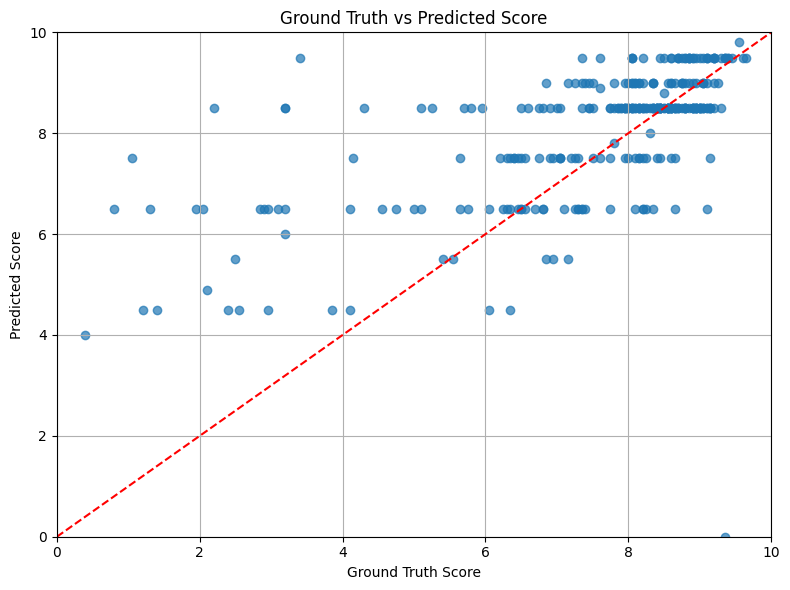

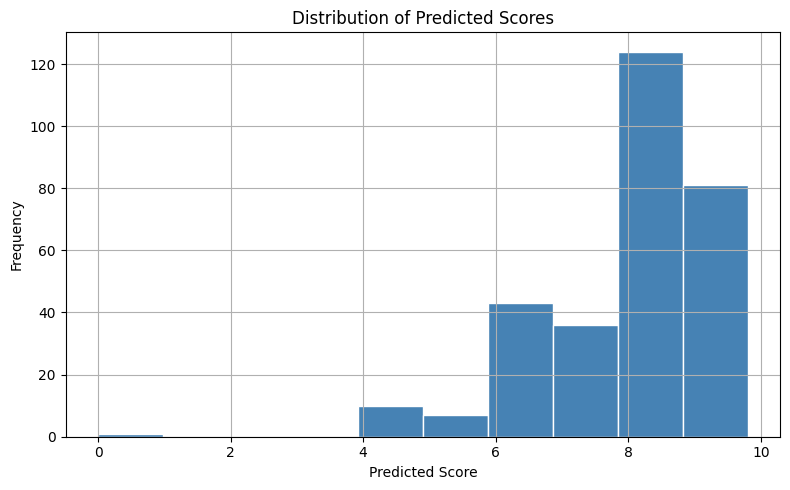

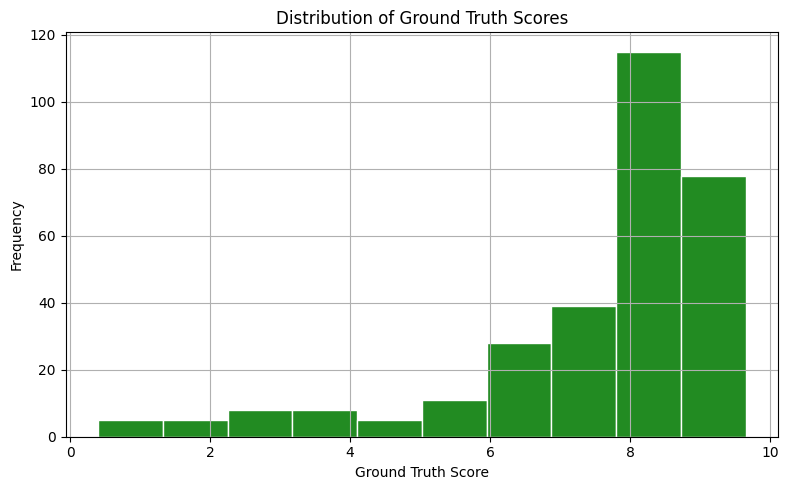

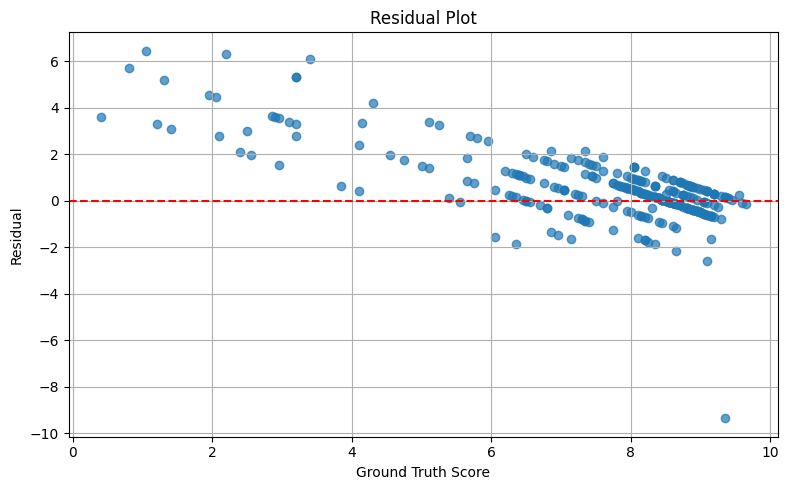

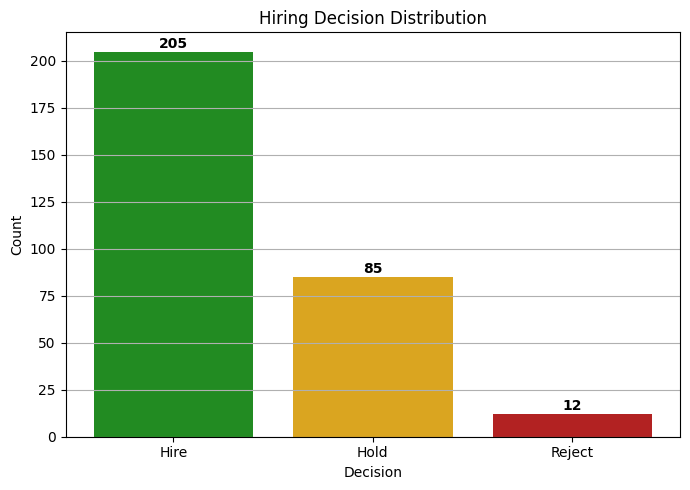

📈 MODEL PERFORMANCE METRICS

Correlation:
  Pearson Correlation  : 0.6137
  Spearman Correlation : 0.6223

Error Metrics:
  Mean Absolute Error (MAE): 0.9776
  Root Mean Squared Error : 1.5828
  R² Score               : 0.2917

Decision Distribution:
  Hire: 205 (67.9%)
  Hold: 85 (28.1%)
  Reject: 12 (4.0%)

Score Statistics:
  Predicted  - Mean: 8.07, Std: 1.30
  Ground Truth - Mean: 7.54, Std: 1.88

✅ Visualization Completed Successfully


In [ ]:
# ============================================================
# SINGLE LLM VISUALIZATION - Using Uploaded Files
# ============================================================

import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr
from google.colab import files

print("=" * 80)
print("SINGLE LLM VISUALIZATION & ANALYSIS")
print("=" * 80)

# ============================================================
# UPLOAD YOUR SAVED FILES
# ============================================================

print("\n📁 Please upload your saved results file:")
print("   - complete_results.json  OR")
print("   - evaluation_results.csv\n")

uploaded = files.upload()

# Determine which file was uploaded
file_name = list(uploaded.keys())[0]

print(f"\n✅ Loaded file: {file_name}")

# ============================================================
# LOAD DATA
# ============================================================

if file_name.endswith('.json'):
    with open(file_name, 'r') as f:
        results_data = json.load(f)
    evaluation_df = pd.DataFrame(results_data)
    print(f"✅ Loaded {len(evaluation_df)} results from JSON")

elif file_name.endswith('.csv'):
    evaluation_df = pd.read_csv(file_name)
    print(f"✅ Loaded {len(evaluation_df)} results from CSV")

else:
    raise ValueError("Unsupported file format. Please upload JSON or CSV.")

# ============================================================
# Convert Ground Truth to 0-10 Scale
# ============================================================

plot_df = evaluation_df.copy()
plot_df["ground_truth_score"] = plot_df["ground_truth_score"] * 10

print(f"\n📊 Dataset Summary:")
print(f"   Total Resumes: {len(plot_df)}")
print(f"   Domains: {plot_df['domain'].nunique()}")
print(f"   Decisions: {plot_df['decision'].nunique()}\n")

# ============================================================
# CREATE ALL 5 PLOTS (from your multi-LLM code)
# ============================================================

# 1. Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(plot_df["ground_truth_score"], plot_df["predicted_score"], alpha=0.7)
plt.plot([0,10], [0,10], linestyle="--", color='red')
plt.xlabel("Ground Truth Score")
plt.ylabel("Predicted Score")
plt.title("Ground Truth vs Predicted Score")
plt.xlim(0,10)
plt.ylim(0,10)
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Prediction Distribution
plt.figure(figsize=(8,5))
plt.hist(plot_df["predicted_score"], bins=10, color='steelblue', edgecolor='white')
plt.xlabel("Predicted Score")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Scores")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Ground Truth Distribution
plt.figure(figsize=(8,5))
plt.hist(plot_df["ground_truth_score"], bins=10, color='forestgreen', edgecolor='white')
plt.xlabel("Ground Truth Score")
plt.ylabel("Frequency")
plt.title("Distribution of Ground Truth Scores")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Residual Plot
residuals = plot_df["predicted_score"] - plot_df["ground_truth_score"]
plt.figure(figsize=(8,5))
plt.scatter(plot_df["ground_truth_score"], residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--", color='red')
plt.xlabel("Ground Truth Score")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Decision Distribution
decision_counts = evaluation_df["decision"].value_counts()
colors = {'Hire': 'forestgreen', 'Hold': 'goldenrod', 'Reject': 'firebrick'}
plt.figure(figsize=(7,5))
bars = plt.bar(decision_counts.index, decision_counts.values,
               color=[colors.get(d, 'gray') for d in decision_counts.index])
plt.xlabel("Decision")
plt.ylabel("Count")
plt.title("Hiring Decision Distribution")
plt.grid(True, axis='y')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# PERFORMANCE METRICS
# ============================================================

print("=" * 80)
print("📈 MODEL PERFORMANCE METRICS")
print("=" * 80)

gt = plot_df["ground_truth_score"]
pred = plot_df["predicted_score"]

pearson_corr, _ = pearsonr(gt, pred)
spearman_corr, _ = spearmanr(gt, pred)

# Calculate additional metrics
mae = np.mean(np.abs(pred - gt))
rmse = np.sqrt(np.mean((pred - gt)**2))
r2 = 1 - (np.sum((pred - gt)**2) / np.sum((gt - np.mean(gt))**2))

print(f"\nCorrelation:")
print(f"  Pearson Correlation  : {pearson_corr:.4f}")
print(f"  Spearman Correlation : {spearman_corr:.4f}")

print(f"\nError Metrics:")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Root Mean Squared Error : {rmse:.4f}")
print(f"  R² Score               : {r2:.4f}")

print(f"\nDecision Distribution:")
for decision, count in decision_counts.items():
    print(f"  {decision}: {count} ({count/len(evaluation_df)*100:.1f}%)")

print(f"\nScore Statistics:")
print(f"  Predicted  - Mean: {plot_df['predicted_score'].mean():.2f}, Std: {plot_df['predicted_score'].std():.2f}")
print(f"  Ground Truth - Mean: {plot_df['ground_truth_score'].mean():.2f}, Std: {plot_df['ground_truth_score'].std():.2f}")

print("\n" + "=" * 80)
print("✅ Visualization Completed Successfully")
print("=" * 80)

SINGLE LLM VISUALIZATION & ANALYSIS

📁 Please upload your saved results file:
   - complete_results.json  OR
   - evaluation_results.csv



Saving complete_results.json to complete_results (3).json
Saving evaluation_results.csv to evaluation_results (3).csv

✅ Loaded file: complete_results (3).json
✅ Loaded 302 results from JSON

📊 Dataset Summary:
   Total Resumes: 302
   Domains: 6
   Decisions: 3



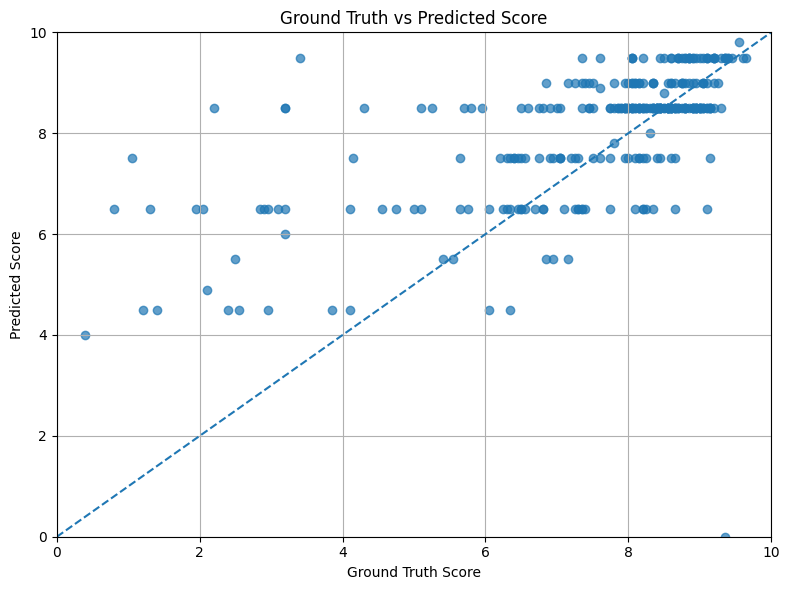

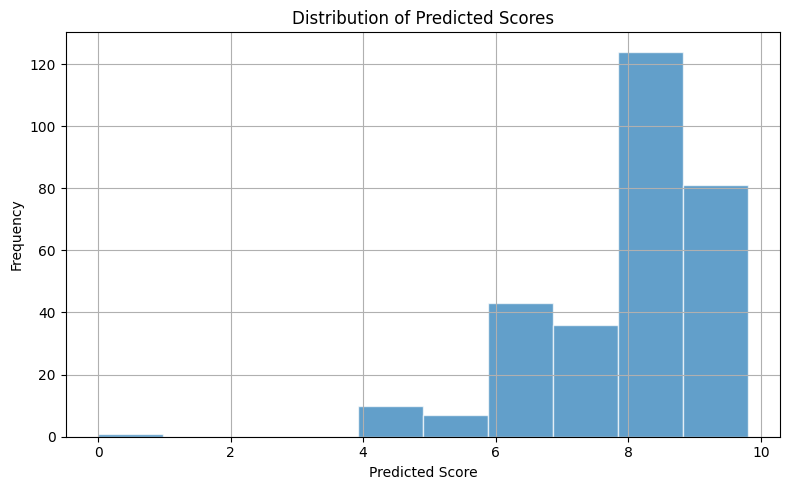

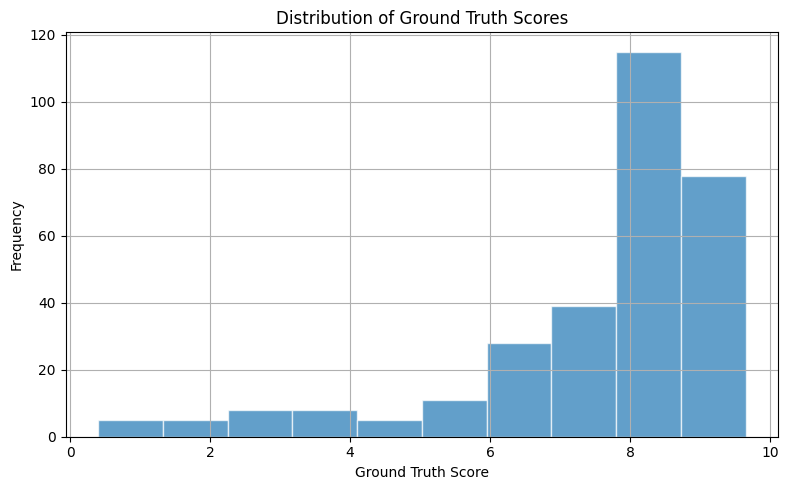

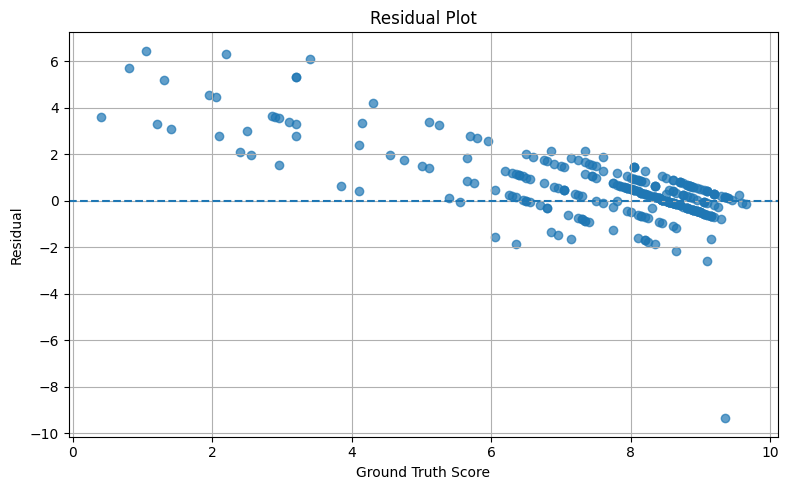

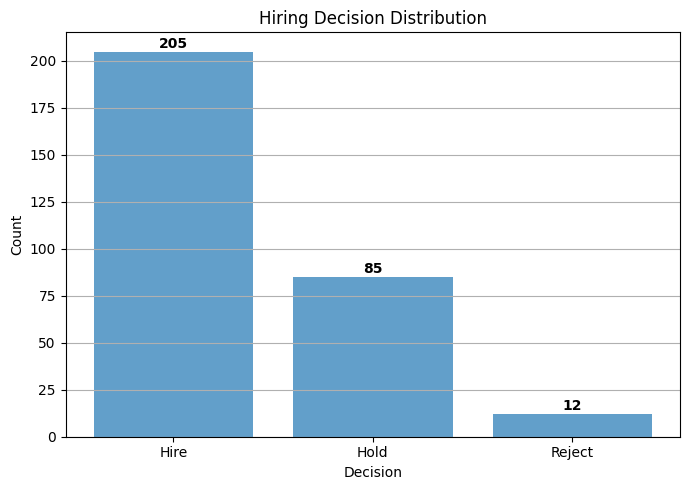

📈 MODEL PERFORMANCE METRICS

Correlation:
  Pearson Correlation  : 0.6137
  Spearman Correlation : 0.6222

Error Metrics:
  Mean Absolute Error (MAE): 0.9776
  Root Mean Squared Error : 1.5828
  R² Score               : 0.2917

Decision Distribution:
  Hire: 205 (67.9%)
  Hold: 85 (28.1%)
  Reject: 12 (4.0%)

Score Statistics:
  Predicted  - Mean: 8.07, Std: 1.30
  Ground Truth - Mean: 7.54, Std: 1.88

✅ Visualization Completed Successfully


In [ ]:
# ============================================================
# SINGLE LLM VISUALIZATION - Using Uploaded Files
# ============================================================

import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr
from google.colab import files

print("=" * 80)
print("SINGLE LLM VISUALIZATION & ANALYSIS")
print("=" * 80)

# ============================================================
# UPLOAD YOUR SAVED FILES
# ============================================================

print("\n📁 Please upload your saved results file:")
print("   - complete_results.json  OR")
print("   - evaluation_results.csv\n")

uploaded = files.upload()

# Determine which file was uploaded
file_name = list(uploaded.keys())[0]

print(f"\n✅ Loaded file: {file_name}")

# ============================================================
# LOAD DATA
# ============================================================

if file_name.endswith('.json'):
    with open(file_name, 'r') as f:
        results_data = json.load(f)
    evaluation_df = pd.DataFrame(results_data)
    print(f"✅ Loaded {len(evaluation_df)} results from JSON")

elif file_name.endswith('.csv'):
    evaluation_df = pd.read_csv(file_name)
    print(f"✅ Loaded {len(evaluation_df)} results from CSV")

else:
    raise ValueError("Unsupported file format. Please upload JSON or CSV.")

# ============================================================
# Convert Ground Truth to 0-10 Scale
# ============================================================

plot_df = evaluation_df.copy()
plot_df["ground_truth_score"] = plot_df["ground_truth_score"] * 10

print(f"\n📊 Dataset Summary:")
print(f"   Total Resumes: {len(plot_df)}")
print(f"   Domains: {plot_df['domain'].nunique()}")
print(f"   Decisions: {plot_df['decision'].nunique()}\n")

# ============================================================
# CREATE ALL 5 PLOTS (with BLUE color only)
# ============================================================

# 1. Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(plot_df["ground_truth_score"], plot_df["predicted_score"], alpha=0.7)
plt.plot([0,10], [0,10], linestyle="--")
plt.xlabel("Ground Truth Score")
plt.ylabel("Predicted Score")
plt.title("Ground Truth vs Predicted Score")
plt.xlim(0,10)
plt.ylim(0,10)
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Prediction Distribution
plt.figure(figsize=(8,5))
plt.hist(plot_df["predicted_score"], bins=10, edgecolor='white', alpha=0.7)
plt.xlabel("Predicted Score")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Scores")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Ground Truth Distribution
plt.figure(figsize=(8,5))
plt.hist(plot_df["ground_truth_score"], bins=10, edgecolor='white', alpha=0.7)
plt.xlabel("Ground Truth Score")
plt.ylabel("Frequency")
plt.title("Distribution of Ground Truth Scores")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Residual Plot
residuals = plot_df["predicted_score"] - plot_df["ground_truth_score"]
plt.figure(figsize=(8,5))
plt.scatter(plot_df["ground_truth_score"], residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Ground Truth Score")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Decision Distribution
decision_counts = evaluation_df["decision"].value_counts()
plt.figure(figsize=(7,5))
bars = plt.bar(decision_counts.index, decision_counts.values, alpha=0.7)
plt.xlabel("Decision")
plt.ylabel("Count")
plt.title("Hiring Decision Distribution")
plt.grid(True, axis='y')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# PERFORMANCE METRICS
# ============================================================

print("=" * 80)
print("📈 MODEL PERFORMANCE METRICS")
print("=" * 80)

gt = plot_df["ground_truth_score"]
pred = plot_df["predicted_score"]

pearson_corr, _ = pearsonr(gt, pred)
spearman_corr, _ = spearmanr(gt, pred)

# Calculate additional metrics
mae = np.mean(np.abs(pred - gt))
rmse = np.sqrt(np.mean((pred - gt)**2))
r2 = 1 - (np.sum((pred - gt)**2) / np.sum((gt - np.mean(gt))**2))

print(f"\nCorrelation:")
print(f"  Pearson Correlation  : {pearson_corr:.4f}")
print(f"  Spearman Correlation : {spearman_corr:.4f}")

print(f"\nError Metrics:")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Root Mean Squared Error : {rmse:.4f}")
print(f"  R² Score               : {r2:.4f}")

print(f"\nDecision Distribution:")
for decision, count in decision_counts.items():
    print(f"  {decision}: {count} ({count/len(evaluation_df)*100:.1f}%)")

print(f"\nScore Statistics:")
print(f"  Predicted  - Mean: {plot_df['predicted_score'].mean():.2f}, Std: {plot_df['predicted_score'].std():.2f}")
print(f"  Ground Truth - Mean: {plot_df['ground_truth_score'].mean():.2f}, Std: {plot_df['ground_truth_score'].std():.2f}")

print("\n" + "=" * 80)
print("✅ Visualization Completed Successfully")
print("=" * 80)